In [1]:
from pyspark.sql import SparkSession

In [2]:
spark = SparkSession.builder.appName("TelecomChurnAnalysis").master("local[*]").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/06/16 11:54:13 WARN Utils: Your hostname, Inishs-MacBook-Pro.local, resolves to a loopback address: 127.0.0.1; using 10.1.7.137 instead (on interface en0)
26/06/16 11:54:13 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/16 11:54:14 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/06/16 11:54:16 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
26/06/16 11:54:16 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from pyspark.ml.feature import *
from pyspark.ml.classification import *
from pyspark.ml import pipeline
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pyspark.sql.functions

In [5]:
df = spark.read.csv("telecom_churn.csv", header = True, inferSchema=True)
df.show(5)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|        TechSupport|        StreamingTV|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|  CUS00001|  Male|            0|    Yes|        No|    42|         Yes|              No|            DSL|                 No|                Yes|                Yes|      One year|             Yes|    Electronic check|         72.56|     305

In [6]:
print("Rows:",df.count())
print("Columns:" , len(df.columns))

Rows: 7043
Columns: 18


In [7]:
from pyspark.sql.functions import sum as spark_sum

missing = df.select([
    spark_sum(when(col(c).isNull(),1).otherwise(0)).alias(c)
    for c in df.columns
])

missing.show()

+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+-----------+-----------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|TechSupport|StreamingTV|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+-----------+-----------+--------+----------------+-------------+--------------+------------+-----+
|         0|     0|            0|      0|         0|     0|           0|            0|              0|             0|          0|          0|       0|               0|            0|             0|          90|    0|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+-----------+-------

In [8]:
for c in df.columns:
    dt = df.schema[c].dataType

    cond = col(c).isNull()
    if isinstance(dt, StringType):
        cond = cond | (trim(col(c)) == '')  # catches '' and '   '

    null_count = df.filter(cond).count()
    if null_count > 0:
        print(c, "->", null_count, "missing values")

TotalCharges -> 90 missing values


In [9]:
df = df.withColumn(
    "TotalCharges",
    when(trim(col("TotalCharges").cast("string")) == "", "0")
    .otherwise(trim(col("TotalCharges").cast("string")))
    .cast(DoubleType())
)

In [10]:
df.select("TotalCharges").show(5)

+------------+
|TotalCharges|
+------------+
|     3052.17|
|     7583.53|
|     1642.77|
|     4458.28|
|     1851.24|
+------------+
only showing top 5 rows


In [11]:
df = df.fillna({'TotalCharges' : 0.0})
remaining_blanks = df.filter (col('TotalCharges').isNull()).count()
print(remaining_blanks)

0


In [12]:
df.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = false)
 |-- Churn: string (nullable = true)



In [13]:
df.select("Churn").show()

+-----+
|Churn|
+-----+
|   No|
|  Yes|
|   No|
|   No|
|   No|
|  Yes|
|   No|
|  Yes|
|  Yes|
|   No|
|  Yes|
|   No|
|  Yes|
|   No|
|   No|
|  Yes|
|  Yes|
|   No|
|  Yes|
|   No|
+-----+
only showing top 20 rows


In [14]:
df = df.withColumn(
    'ChurnLabel',
    when(col('Churn') == 'Yes', 1.0).otherwise(0.0)
)

df.groupBy("ChurnLabel").count().show()

+----------+-----+
|ChurnLabel|count|
+----------+-----+
|       0.0| 5277|
|       1.0| 1766|
+----------+-----+



In [15]:
df.select('Partner').show()

+-------+
|Partner|
+-------+
|    Yes|
|    Yes|
|     No|
|    Yes|
|    Yes|
|    Yes|
|    Yes|
|     No|
|     No|
|     No|
|     No|
|     No|
|     No|
|     No|
|    Yes|
|     No|
|     No|
|     No|
|     No|
|    Yes|
+-------+
only showing top 20 rows


In [16]:
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'TechSupport', 'StreamingTV', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [17]:
indexers = []
for c in cat_cols:
    idx = StringIndexer(inputCol= c , outputCol= c + '_idx', handleInvalid= 'keep')
    indexers.append(idx)
len(indexers)

12

In [18]:
encoders = []
for c in cat_cols:
    enc = OneHotEncoder(inputCol= c + '_idx',  outputCol= c + '_ohe', dropLast = True)
    encoders.append(enc)

len(encoders)

12

In [19]:
ohe_cols = [c + '_ohe' for c in cat_cols]
all_feature_cols = num_cols + ohe_cols

assembler = VectorAssembler(inputCols = all_feature_cols, outputCol= 'features', handleInvalid= 'keep')

In [20]:
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [21]:
from pyspark.ml import Pipeline

In [22]:
prep_pipeline = Pipeline(stages = indexers + encoders +[assembler])
prep_model = prep_pipeline.fit(df)
df_prep = prep_model.transform(df)
df_prep.select("InternetService_ohe").show(5)

+-------------------+
|InternetService_ohe|
+-------------------+
|      (3,[1],[1.0])|
|      (3,[0],[1.0])|
|      (3,[2],[1.0])|
|      (3,[2],[1.0])|
|      (3,[0],[1.0])|
+-------------------+
only showing top 5 rows


In [23]:
train_data , test_data = df_prep.randomSplit([0.7, 0.3], seed = 42)
print(train_data.count())
print(test_data.count())

26/06/16 11:56:50 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


5036
2007


In [24]:
train_data.groupBy('ChurnLabel').count().show()

+----------+-----+
|ChurnLabel|count|
+----------+-----+
|       0.0| 3781|
|       1.0| 1255|
+----------+-----+



In [25]:
test_data.groupBy('ChurnLabel').count().show()

+----------+-----+
|ChurnLabel|count|
+----------+-----+
|       0.0| 1496|
|       1.0|  511|
+----------+-----+



In [26]:
logR = LogisticRegression(
    labelCol= 'ChurnLabel',
    featuresCol= 'features',
    maxIter= 100,
    regParam = 0.01
)

print("Regression Model")

lr_model = logR.fit(train_data)
print(lr_model)

Regression Model


26/06/16 11:57:21 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS


LogisticRegressionModel: uid=LogisticRegression_940b0f0d1b0f, numClasses=2, numFeatures=36


In [27]:
lr_pred = lr_model.transform(test_data)

for c in lr_pred.columns[-5:]:
    print(c)

PaymentMethod_ohe
features
rawPrediction
probability
prediction


In [28]:
lr_pred.select (
'customerID', 'ChurnLabel', 'rawPrediction', "probability", 'prediction').show(5)

+----------+----------+--------------------+--------------------+----------+
|customerID|ChurnLabel|       rawPrediction|         probability|prediction|
+----------+----------+--------------------+--------------------+----------+
|  CUS00003|       0.0|[1.22555480001600...|[0.77303961345466...|       0.0|
|  CUS00007|       0.0|[2.23779686486223...|[0.90359270731639...|       0.0|
|  CUS00009|       1.0|[0.69730973030122...|[0.66759103509732...|       0.0|
|  CUS00010|       0.0|[1.70109732381818...|[0.84567799737913...|       0.0|
|  CUS00014|       0.0|[0.67944909609309...|[0.66361573027120...|       0.0|
+----------+----------+--------------------+--------------------+----------+
only showing top 5 rows


In [29]:
from pyspark.ml.evaluation import *

In [30]:
evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol='ChurnLabel', predictionCol='prediction', metricName='f1'
)

lr_f1_eval = evaluator_f1.evaluate(lr_pred)
print(lr_f1_eval)

0.6816304449219187


In [31]:
lr_TP = lr_pred.filter((col('ChurnLabel') == 1) & (col('prediction') == 1)).count()
lr_TN = lr_pred.filter((col('ChurnLabel') == 0) & (col('prediction') == 0)).count()
lr_FP = lr_pred.filter((col('ChurnLabel') == 0) & (col('prediction') == 1)).count()
lr_FN = lr_pred.filter((col('ChurnLabel') == 1) & (col('prediction') == 0)).count()


print("TP" , lr_TP)
print("TN", lr_TN)
print("FP", lr_FP)
print("FN", lr_FN)

TP 63
TN 1429
FP 67
FN 448


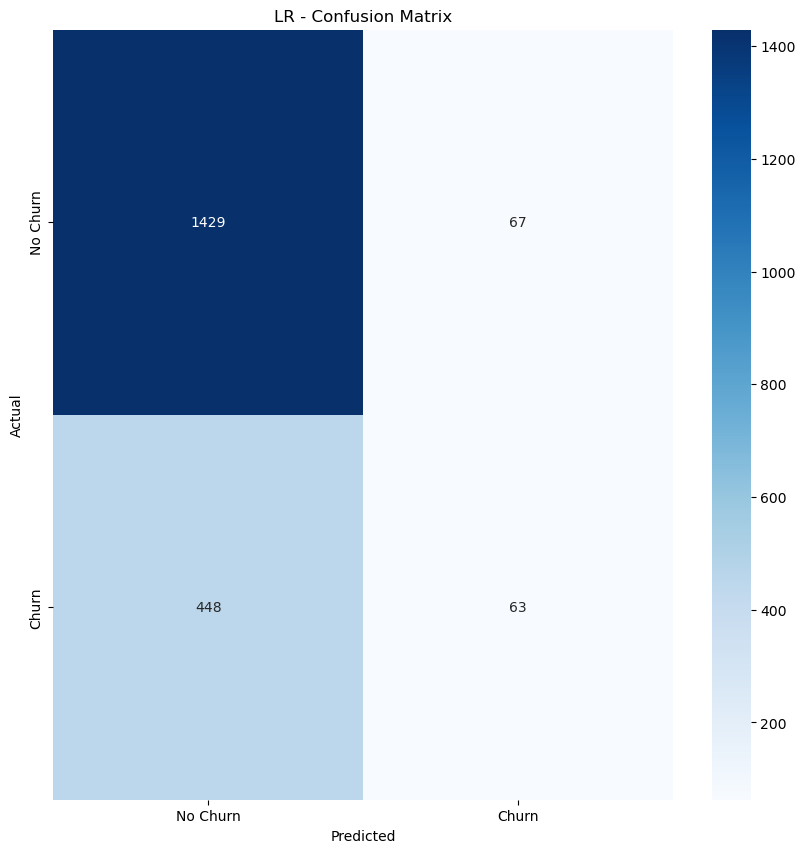

In [32]:
cm = np.array([[lr_TN, lr_FP], [lr_FN, lr_TP]])

plt.figure(figsize= (10,10))
sns.heatmap(cm , annot = True ,
           xticklabels= ["No Churn", 'Churn'],
           yticklabels=['No Churn', 'Churn'],
           cmap= 'Blues',
           fmt = "d")
plt.title("LR - Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel("Predicted")
plt.show()

# Implementing Naive Bayes Classification Algorithm

In [33]:
from pyspark.ml.classification import NaiveBayes
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.sql.functions import col

In [34]:
nb = NaiveBayes(
    labelCol="ChurnLabel",
    featuresCol="features",
    modelType="multinomial",   
    smoothing=1.0
)

In [35]:
nb_model = nb.fit(train_data)
nb_pred  = nb_model.transform(test_data)

In [36]:
nb_pred.select("customerID", "ChurnLabel", "probability", "prediction").show(5, truncate=False)

+----------+----------+------------------------------------------+----------+
|customerID|ChurnLabel|probability                               |prediction|
+----------+----------+------------------------------------------+----------+
|CUS00003  |0.0       |[0.9969195481677404,0.0030804518322595457]|0.0       |
|CUS00007  |0.0       |[0.9937710965224674,0.006228903477532693] |0.0       |
|CUS00009  |1.0       |[0.879643472567111,0.12035652743288891]   |0.0       |
|CUS00010  |0.0       |[0.37026619258125365,0.6297338074187465]  |1.0       |
|CUS00014  |0.0       |[0.017951353305135444,0.9820486466948647] |1.0       |
+----------+----------+------------------------------------------+----------+
only showing top 5 rows


In [37]:
evaluator_f1 = MulticlassClassificationEvaluator(
    labelCol="ChurnLabel", predictionCol="prediction", metricName="f1"
)

In [38]:
evaluator_acc = MulticlassClassificationEvaluator(
    labelCol="ChurnLabel", predictionCol="prediction", metricName="accuracy"
)

In [39]:
nb_f1  = evaluator_f1.evaluate(nb_pred)
nb_acc = evaluator_acc.evaluate(nb_pred)

print("Naive Bayes (Multinomial) F1 :", nb_f1)
print("Naive Bayes (Multinomial) Acc:", nb_acc)

Naive Bayes (Multinomial) F1 : 0.6618737793965958
Naive Bayes (Multinomial) Acc: 0.6502242152466368


In [40]:
nb_TP = nb_pred.filter((col("ChurnLabel")==1) & (col("prediction")==1)).count()
nb_TN = nb_pred.filter((col("ChurnLabel")==0) & (col("prediction")==0)).count()
nb_FP = nb_pred.filter((col("ChurnLabel")==0) & (col("prediction")==1)).count()
nb_FN = nb_pred.filter((col("ChurnLabel")==1) & (col("prediction")==0)).count()

print("TP", nb_TP)
print("TN", nb_TN)
print("FP", nb_FP)
print("FN", nb_FN)

TP 224
TN 1081
FP 415
FN 287


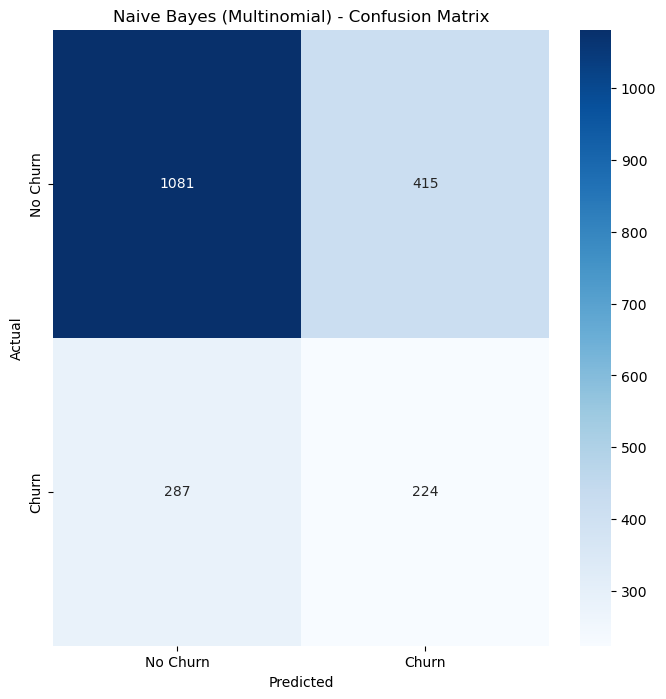

In [41]:
cm_nb = np.array([[nb_TN, nb_FP],
                  [nb_FN, nb_TP]])

plt.figure(figsize=(8,8))
sns.heatmap(cm_nb, annot=True,
            xticklabels=["No Churn","Churn"],
            yticklabels=["No Churn","Churn"],
            cmap="Blues", fmt="d")
plt.title("Naive Bayes (Multinomial) - Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()